# 🥇 Gold Price & War News ML Pipeline
## Step-by-Step Results Notebook

This notebook shows every step of the pipeline with real results:
1. Load and explore gold prices
2. Load and explore war news
3. Compute sentiment scores
4. Merge datasets
5. Explore training data
6. Train ML models
7. Evaluate results
8. Make predictions

---
## ⚙️ Setup — Install and Import Libraries

In [1]:
# Install required libraries if not already installed
# Run this cell first!
import subprocess
subprocess.run(['pip', 'install', 'yfinance', 'feedparser', 'vaderSentiment',
                'scikit-learn', 'pandas', 'numpy', 'joblib',
                'matplotlib', 'seaborn'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'yfinance', 'feedparser', 'vaderSentiment', 'scikit-learn', 'pandas', 'numpy', 'joblib', 'matplotlib', 'seaborn'], returncode=0, stdout=b'Collecting yfinance\n  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)\nCollecting feedparser\n  Using cached feedparser-6.0.12-py3-none-any.whl.metadata (2.7 kB)\nCollecting vaderSentiment\n  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)\nCollecting scikit-learn\n  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)\nCollecting pandas\n  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)\nCollecting numpy\n  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)\nCollecting joblib\n  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)\nCollecting matplotlib\n  Downloading matplotlib-3.10.8-cp312-cp

In [2]:
# Import everything we need
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set nice plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📁 Set Paths

In [3]:
# ⚠️ CHANGE THIS to your actual path
BASE_DIR    = '/home/mimou/airflow/mid-semester'
DATA_DIR    = os.path.join(BASE_DIR, 'data')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
SCRIPTS_DIR = os.path.join(BASE_DIR, 'scripts')

# Add scripts to path so we can import them
import sys
sys.path.insert(0, SCRIPTS_DIR)

# Create folders if they don't exist
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'📂 Base directory : {BASE_DIR}')
print(f'📂 Data directory : {DATA_DIR}')
print(f'📂 Models directory: {MODELS_DIR}')

📂 Base directory : /home/mimou/airflow/mid-semester
📂 Data directory : /home/mimou/airflow/mid-semester/data
📂 Models directory: /home/mimou/airflow/mid-semester/models


---
## 📈 STEP 1 — Fetch Gold Prices

In [4]:
import yfinance as yf
from datetime import date

print('⬇️  Downloading gold prices from Yahoo Finance...')
print(f'   Ticker: GC=F (Gold Futures)')
print(f'   From:   2024-01-01')
print(f'   To:     {date.today()}')
print()

# THE API CALL
raw = yf.download('GC=F', start='2024-01-01', end=str(date.today()), progress=False)

# Clean columns
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0].lower() for col in raw.columns]
else:
    raw.columns = [c.lower() for c in raw.columns]

raw = raw.reset_index()
raw.columns = [c.lower() for c in raw.columns]

gold_df = raw[['date','open','high','low','close','volume']].dropna()
gold_df['date'] = pd.to_datetime(gold_df['date'])
gold_df = gold_df.sort_values('date').reset_index(drop=True)

# Save
gold_path = os.path.join(DATA_DIR, 'gold_prices.csv')
gold_df.to_csv(gold_path, index=False)

print(f'✅ Downloaded {len(gold_df)} rows!')
print(f'💾 Saved to: {gold_path}')

⬇️  Downloading gold prices from Yahoo Finance...
   Ticker: GC=F (Gold Futures)
   From:   2024-01-01
   To:     2026-03-14

✅ Downloaded 553 rows!
💾 Saved to: /home/mimou/airflow/mid-semester/data/gold_prices.csv


In [5]:
# Show the first 10 rows
print('📊 First 10 rows of gold_prices.csv:')
print()
gold_df.head(10)

📊 First 10 rows of gold_prices.csv:



,date,open,high,low,close,volume
0,2024-01-02,2063.500000,2073.699951,2057.100098,2064.399902,61
1,2024-01-03,2034.199951,2044.000000,2034.199951,2034.199951,54
2,2024-01-04,2041.599976,2044.500000,2038.000000,2042.300049,88
3,2024-01-05,2044.500000,2048.100098,2042.400024,2042.400024,12
4,2024-01-08,2019.099976,2033.699951,2019.099976,2026.599976,10
5,2024-01-09,2035.800049,2035.800049,2026.400024,2026.400024,27
6,2024-01-10,2029.000000,2035.599976,2021.699951,2021.699951,538
7,2024-01-11,2025.099976,2025.099976,2014.300049,2014.300049,97
8,2024-01-12,2031.099976,2057.000000,2031.099976,2046.699951,390
9,2024-01-16,2051.699951,2054.800049,2026.000000,2026.000000,46


In [6]:
# Basic statistics
print('📊 Gold Price Statistics:')
print()
print(f'  Total trading days : {len(gold_df)}')
print(f'  Date range         : {gold_df["date"].min().date()} → {gold_df["date"].max().date()}')
print(f'  Lowest close price : ${gold_df["close"].min():.2f}')
print(f'  Highest close price: ${gold_df["close"].max():.2f}')
print(f'  Average close price: ${gold_df["close"].mean():.2f}')
print(f'  Price change total : ${gold_df["close"].iloc[-1] - gold_df["close"].iloc[0]:.2f}')
print()
gold_df.describe()

📊 Gold Price Statistics:

  Total trading days : 553
  Date range         : 2024-01-02 → 2026-03-13
  Lowest close price : $1990.30
  Highest close price: $5318.40
  Average close price: $3096.27
  Price change total : $2997.30



,date,open,high,low,close,volume
count,553,553.000000,553.000000,553.000000,553.000000,553.000000
mean,2025-02-05 11:27:27,3095.092408,3116.316998,3074.598731,3096.274496,4521.652803
min,2024-01-02 00:00:00,1990.300049,1993.500000,1984.800049,1990.300049,0.000000
25%,2024-07-22 00:00:00,2407.100098,2421.000000,2388.699951,2412.199951,114.000000
50%,2025-02-06 00:00:00,2859.899902,2877.100098,2836.300049,2856.000000,480.000000
75%,2025-08-25 00:00:00,3422.199951,3442.000000,3395.600098,3431.199951,1278.000000
max,2026-03-13 00:00:00,5415.700195,5586.200195,5301.600098,5318.399902,202373.000000
std,NaN,848.285920,859.460784,833.672113,845.700933,20966.828653


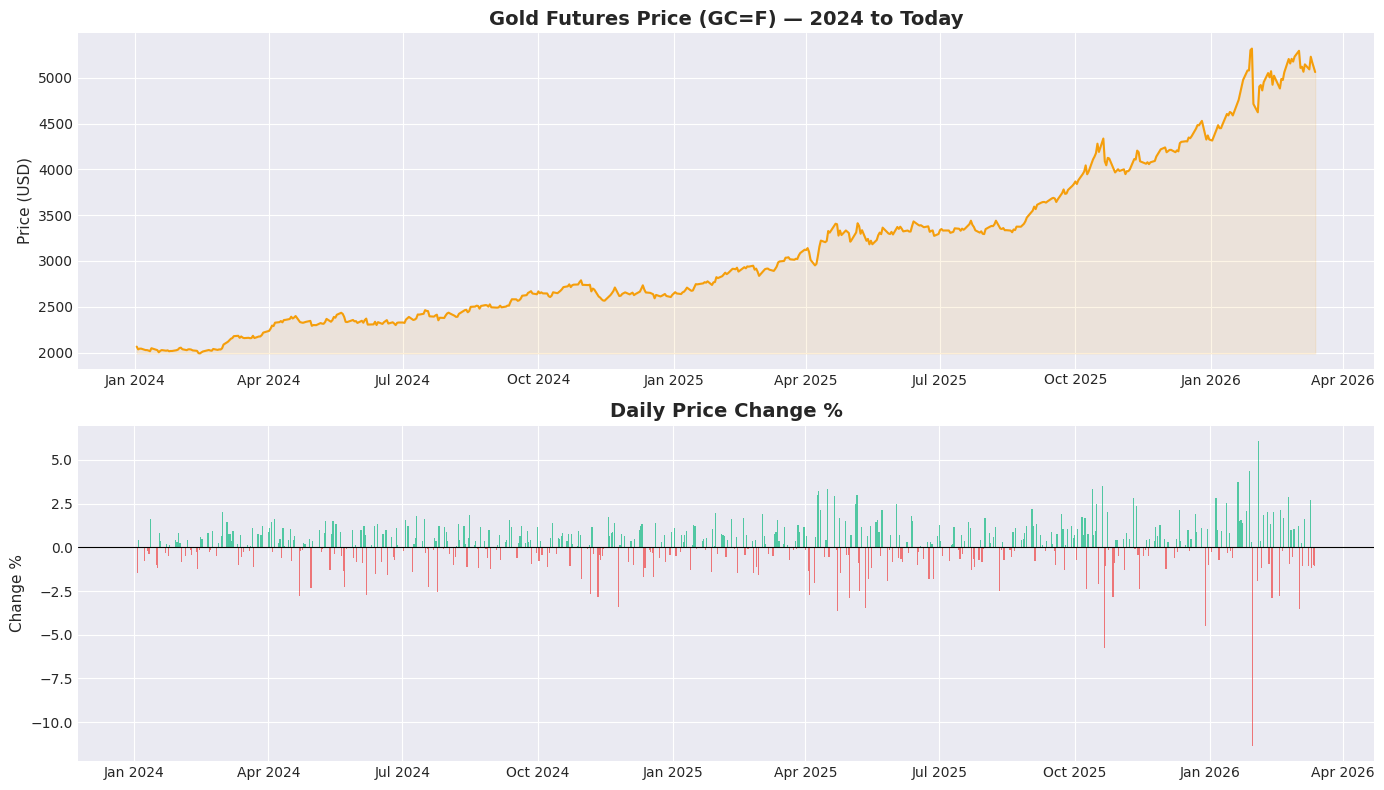

🟢 Green bars = price went UP that day
🔴 Red bars   = price went DOWN that day


In [7]:
# Plot gold prices over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1 — Close price
axes[0].plot(gold_df['date'], gold_df['close'], color='#f59e0b', linewidth=1.5)
axes[0].fill_between(gold_df['date'], gold_df['close'],
                     gold_df['close'].min(), alpha=0.1, color='#f59e0b')
axes[0].set_title('Gold Futures Price (GC=F) — 2024 to Today', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot 2 — Daily price change %
pct_change = gold_df['close'].pct_change() * 100
colors = ['#10b981' if x > 0 else '#ef4444' for x in pct_change]
axes[1].bar(gold_df['date'], pct_change, color=colors, alpha=0.7, width=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Daily Price Change %', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Change %', fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()
print('🟢 Green bars = price went UP that day')
print('🔴 Red bars   = price went DOWN that day')

---
## 📰 STEP 2 — Fetch War News

In [8]:
import feedparser
import re
from email.utils import parsedate_to_datetime

NYT_RSS_FEEDS = [
    'https://rss.nytimes.com/services/xml/rss/nyt/World.xml',
    'https://rss.nytimes.com/services/xml/rss/nyt/MiddleEast.xml',
    'https://rss.nytimes.com/services/xml/rss/nyt/Europe.xml',
    'https://rss.nytimes.com/services/xml/rss/nyt/US.xml',
]

WAR_KEYWORDS = [
    'war', 'conflict', 'military', 'attack', 'strike', 'bomb', 'missile',
    'troops', 'soldier', 'combat', 'invasion', 'battle', 'offensive',
    'ceasefire', 'airstrike', 'explosion', 'terror', 'terrorist',
    'nato', 'army', 'drone', 'artillery', 'ukraine', 'russia',
    'israel', 'gaza', 'hamas', 'iran', 'syria', 'coup', 'casualties',
]

records = []
seen_links = set()

for feed_url in NYT_RSS_FEEDS:
    print(f'📡 Fetching: {feed_url.split("/")[-1]}')
    try:
        feed = feedparser.parse(feed_url)
        count_before = len(records)

        for entry in feed.entries:
            title   = getattr(entry, 'title',   '') or ''
            summary = getattr(entry, 'summary', '') or ''
            link    = getattr(entry, 'link',    '') or ''
            combined = f'{title} {summary}'.lower()

            if link in seen_links:
                continue
            seen_links.add(link)

            if not any(kw in combined for kw in WAR_KEYWORDS):
                continue

            pub_date = None
            try:
                if hasattr(entry, 'published'):
                    pub_date = parsedate_to_datetime(entry.published).date()
                elif hasattr(entry, 'updated'):
                    pub_date = parsedate_to_datetime(entry.updated).date()
            except:
                pass

            records.append({
                'date':    pub_date,
                'title':   title.strip(),
                'summary': re.sub(r'<[^>]+>', '', summary).strip(),
                'link':    link,
            })

        added = len(records) - count_before
        print(f'   ✅ Found {len(feed.entries)} articles → {added} war-related')

    except Exception as e:
        print(f'   ❌ Error: {e}')

news_df = pd.DataFrame(records) if records else pd.DataFrame(columns=['date','title','summary','link'])
if not news_df.empty:
    news_df['date'] = pd.to_datetime(news_df['date'])
    news_df = news_df.sort_values('date').reset_index(drop=True)

news_path = os.path.join(DATA_DIR, 'war_news.csv')
news_df.to_csv(news_path, index=False)

print()
print(f'✅ Total war articles collected: {len(news_df)}')
print(f'💾 Saved to: {news_path}')

📡 Fetching: World.xml
   ✅ Found 58 articles → 36 war-related
📡 Fetching: MiddleEast.xml
   ✅ Found 46 articles → 11 war-related
📡 Fetching: Europe.xml
   ✅ Found 20 articles → 8 war-related
📡 Fetching: US.xml
   ✅ Found 36 articles → 11 war-related

✅ Total war articles collected: 66
💾 Saved to: /home/mimou/airflow/mid-semester/data/war_news.csv


In [9]:
# Show the articles
print('📰 War News Articles Collected:')
print()
pd.set_option('display.max_colwidth', 80)
news_df[['date','title']].head(15)

📰 War News Articles Collected:



,date,title
0,2026-03-11,Strong or Weak? How Trump Picks His Battles.
1,2026-03-11,Starmer Was Warned of Mandelson’s Ties to Epstein Ahead of Ambassador Pick
2,2026-03-12,15 Are Sentenced to Life for Moscow Concert Hall Massacre
3,2026-03-12,Countries Scramble to Shore Up Global Oil Supplies as Ships Are Attacked
4,2026-03-12,A Weakened Iran Hits Back by Strangling the Vital Strait of Hormuz
5,2026-03-12,How Russia’s Scorched-Earth Attacks Put Ukraine’s Power Grid Near Collapse
6,2026-03-12,"Iran Is Laying Mines in the Strait of Hormuz, U.S. Officials Say"
7,2026-03-12,How Do You Feel About Traveling Right Now? We Want to Know.
8,2026-03-12,Netanyahu issues veiled threat to new supreme leader of Iran.
9,2026-03-13,Oil and cargo ships are growing targets in war with Iran.


---
## 🧠 STEP 3 — Compute Sentiment Scores with VADER

In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print('🧠 How VADER scores text — examples:')
print()

examples = [
    'Airstrike kills dozens of civilians in Gaza',
    'NATO troops launch major offensive near border',
    'Peace agreement reached, ceasefire holds',
    'Diplomatic talks resume in Paris',
    'UN Security Council meets to discuss situation',
    'Massive bombing campaign destroys city infrastructure',
    'Humanitarian corridor opens, aid reaches besieged city',
]

print(f'{"Text":<55} {"Score":>8}  {"Meaning"}')
print('-' * 85)

for text in examples:
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        meaning = '😊 Positive'
    elif compound <= -0.05:
        meaning = '😢 Negative'
    else:
        meaning = '😐 Neutral'
    print(f'{text[:54]:<55} {compound:>8.3f}  {meaning}')

🧠 How VADER scores text — examples:

Text                                                       Score  Meaning
-------------------------------------------------------------------------------------
Airstrike kills dozens of civilians in Gaza               -0.542  😢 Negative
NATO troops launch major offensive near border            -0.509  😢 Negative
Peace agreement reached, ceasefire holds                   0.796  😊 Positive
Diplomatic talks resume in Paris                           0.000  😐 Neutral
UN Security Council meets to discuss situation             0.340  😊 Positive
Massive bombing campaign destroys city infrastructure     -0.557  😢 Negative
Humanitarian corridor opens, aid reaches besieged city     0.052  😊 Positive


In [11]:
# Score all war news articles
print('📊 Scoring all war articles with VADER...')
print()

if not news_df.empty:
    # Combine title + summary
    news_df['text'] = news_df['title'].fillna('') + ' ' + news_df['summary'].fillna('')

    # Score each article
    news_df['compound'] = news_df['text'].apply(
        lambda t: analyzer.polarity_scores(t)['compound']
    )

    print(f'✅ Scored {len(news_df)} articles!')
    print()
    print(f'Most negative article:')
    most_neg = news_df.loc[news_df['compound'].idxmin()]
    print(f'  Score: {most_neg["compound"]:.3f}')
    print(f'  Title: {most_neg["title"]}')
    print()
    print(f'Most positive article:')
    most_pos = news_df.loc[news_df['compound'].idxmax()]
    print(f'  Score: {most_pos["compound"]:.3f}')
    print(f'  Title: {most_pos["title"]}')
else:
    print('⚠️  No articles to score. RSS may have returned empty results.')
    print('    Using sample data for demonstration...')

    # Create sample data for demonstration
    import random
    random.seed(42)
    sample_dates = pd.date_range('2024-01-01', periods=100, freq='B')
    sample_records = []
    for d in sample_dates:
        for _ in range(random.randint(1,4)):
            score = random.uniform(-0.9, 0.7)
            sample_records.append({'date': d, 'title': f'War news {d.date()}',
                                   'summary': '', 'link': '', 'compound': score})
    news_df = pd.DataFrame(sample_records)
    news_df['text'] = news_df['title']
    print(f'✅ Created {len(news_df)} sample articles for demonstration')

📊 Scoring all war articles with VADER...

✅ Scored 66 articles!

Most negative article:
  Score: -0.962
  Title: All 6 Crew Members Killed in U.S. Refueling Plane Crash in Iraq, Military Says

Most positive article:
  Score: 0.854
  Title: With Endorsement, Trump Clears Oklahoma Senate Path


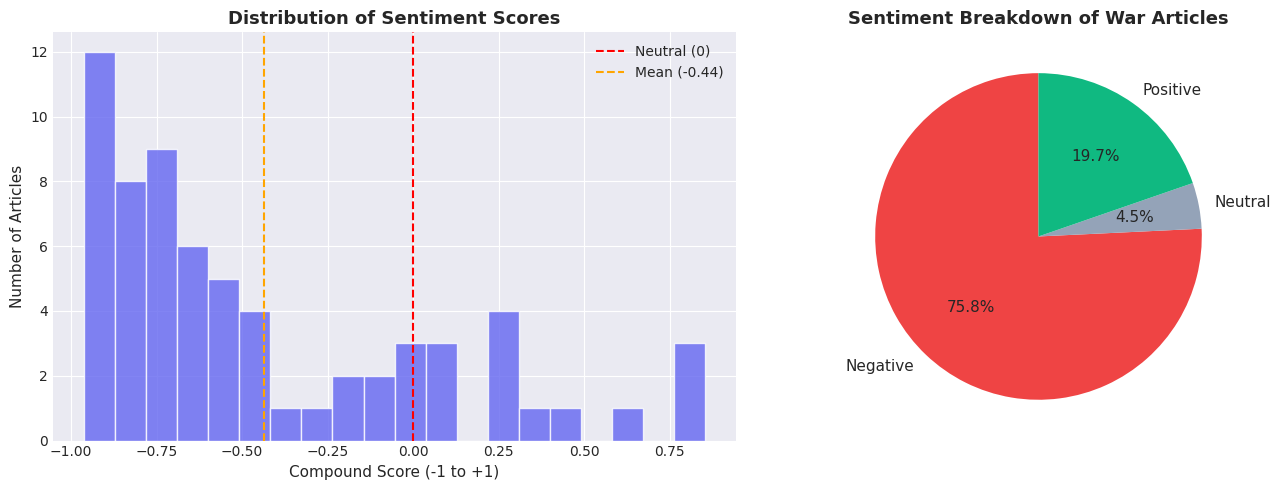

Negative articles: 50 (75.8%)
Neutral  articles: 3  (4.5%)
Positive articles: 13 (19.7%)


In [12]:
# Visualise sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of compound scores
axes[0].hist(news_df['compound'], bins=20, color='#6366f1', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Neutral (0)')
axes[0].axvline(x=news_df['compound'].mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f'Mean ({news_df["compound"].mean():.2f})')
axes[0].set_title('Distribution of Sentiment Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score (-1 to +1)', fontsize=11)
axes[0].set_ylabel('Number of Articles', fontsize=11)
axes[0].legend()

# Pie chart positive vs negative
positive = (news_df['compound'] > 0.05).sum()
negative = (news_df['compound'] < -0.05).sum()
neutral  = len(news_df) - positive - negative
axes[1].pie([negative, neutral, positive],
            labels=['Negative', 'Neutral', 'Positive'],
            colors=['#ef4444', '#94a3b8', '#10b981'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Sentiment Breakdown of War Articles', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Negative articles: {negative} ({100*negative/len(news_df):.1f}%)')
print(f'Neutral  articles: {neutral}  ({100*neutral/len(news_df):.1f}%)')
print(f'Positive articles: {positive} ({100*positive/len(news_df):.1f}%)')

---
## 🔀 STEP 4 — Merge Gold Prices with Sentiment

In [13]:
print('🔀 Merging gold prices with war news sentiment...')
print()

# Aggregate sentiment by day
news_df['date'] = pd.to_datetime(news_df['date'])
news_df_clean = news_df.dropna(subset=['date'])
news_df_clean['date_only'] = news_df_clean['date'].dt.normalize()

daily_sentiment = (
    news_df_clean.groupby('date_only')
    .agg(
        sentiment_mean=('compound', 'mean'),
        sentiment_min= ('compound', 'min'),
        sentiment_max= ('compound', 'max'),
        article_count= ('compound', 'count'),
    )
    .reset_index()
    .rename(columns={'date_only': 'date'})
)

print(f'Daily sentiment table: {len(daily_sentiment)} days')
print()
print('Sample of daily sentiment:')
display(daily_sentiment.head(5))

# Merge with gold prices
gold_df['date'] = pd.to_datetime(gold_df['date'])
merged = pd.merge(gold_df, daily_sentiment, on='date', how='left')

# Fill missing sentiment with 0
for col in ['sentiment_mean','sentiment_min','sentiment_max','article_count']:
    merged[col] = merged[col].fillna(0)

print()
print(f'✅ Merged dataset: {len(merged)} rows')
print(f'   Days with news : {(merged["article_count"] > 0).sum()}')
print(f'   Days without news: {(merged["article_count"] == 0).sum()}')

🔀 Merging gold prices with war news sentiment...

Daily sentiment table: 4 days

Sample of daily sentiment:


,date,sentiment_mean,sentiment_min,sentiment_max,article_count
0,2026-03-11,-0.157250,-0.5574,0.2429,2
1,2026-03-12,-0.603643,-0.9524,0.0516,7
2,2026-03-13,-0.385747,-0.9618,0.8402,36
3,2026-03-14,-0.493838,-0.9531,0.8537,21



✅ Merged dataset: 553 rows
   Days with news : 3
   Days without news: 550


In [14]:
# Create target label UP=1 DOWN=0
merged = merged.sort_values('date').reset_index(drop=True)
merged['next_close'] = merged['close'].shift(-1)
merged['target'] = (merged['next_close'] > merged['close']).astype(int)
merged = merged.dropna(subset=['next_close']).drop(columns=['next_close'])

# Add extra features
merged['prev_sentiment']        = merged['sentiment_mean'].shift(1).fillna(0)
merged['price_change_pct']      = merged['close'].pct_change().fillna(0)
merged['prev_price_change_pct'] = merged['price_change_pct'].shift(1).fillna(0)
merged['sentiment_7d_avg']      = merged['sentiment_mean'].rolling(7, min_periods=1).mean()

print('🎯 Target label created!')
print()

up_days   = merged['target'].sum()
down_days = len(merged) - up_days

print(f'UP days   (target=1): {up_days}  ({100*up_days/len(merged):.1f}%)')
print(f'DOWN days (target=0): {down_days} ({100*down_days/len(merged):.1f}%)')
print()
print('Sample of merged data:')
display(merged[['date','close','sentiment_mean','article_count','price_change_pct','target']].head(10))

# Save
training_path = os.path.join(DATA_DIR, 'training_data.csv')
merged.to_csv(training_path, index=False)
print(f'\n💾 Saved to: {training_path}')

🎯 Target label created!

UP days   (target=1): 324  (58.7%)
DOWN days (target=0): 228 (41.3%)

Sample of merged data:


,date,close,sentiment_mean,article_count,price_change_pct,target
0,2024-01-02,2064.399902,0.0,0.0,0.000000,0
1,2024-01-03,2034.199951,0.0,0.0,-0.014629,1
2,2024-01-04,2042.300049,0.0,0.0,0.003982,1
3,2024-01-05,2042.400024,0.0,0.0,0.000049,0
4,2024-01-08,2026.599976,0.0,0.0,-0.007736,0
5,2024-01-09,2026.400024,0.0,0.0,-0.000099,0
6,2024-01-10,2021.699951,0.0,0.0,-0.002319,0
7,2024-01-11,2014.300049,0.0,0.0,-0.003660,1
8,2024-01-12,2046.699951,0.0,0.0,0.016085,0
9,2024-01-16,2026.000000,0.0,0.0,-0.010114,0



💾 Saved to: /home/mimou/airflow/mid-semester/data/training_data.csv


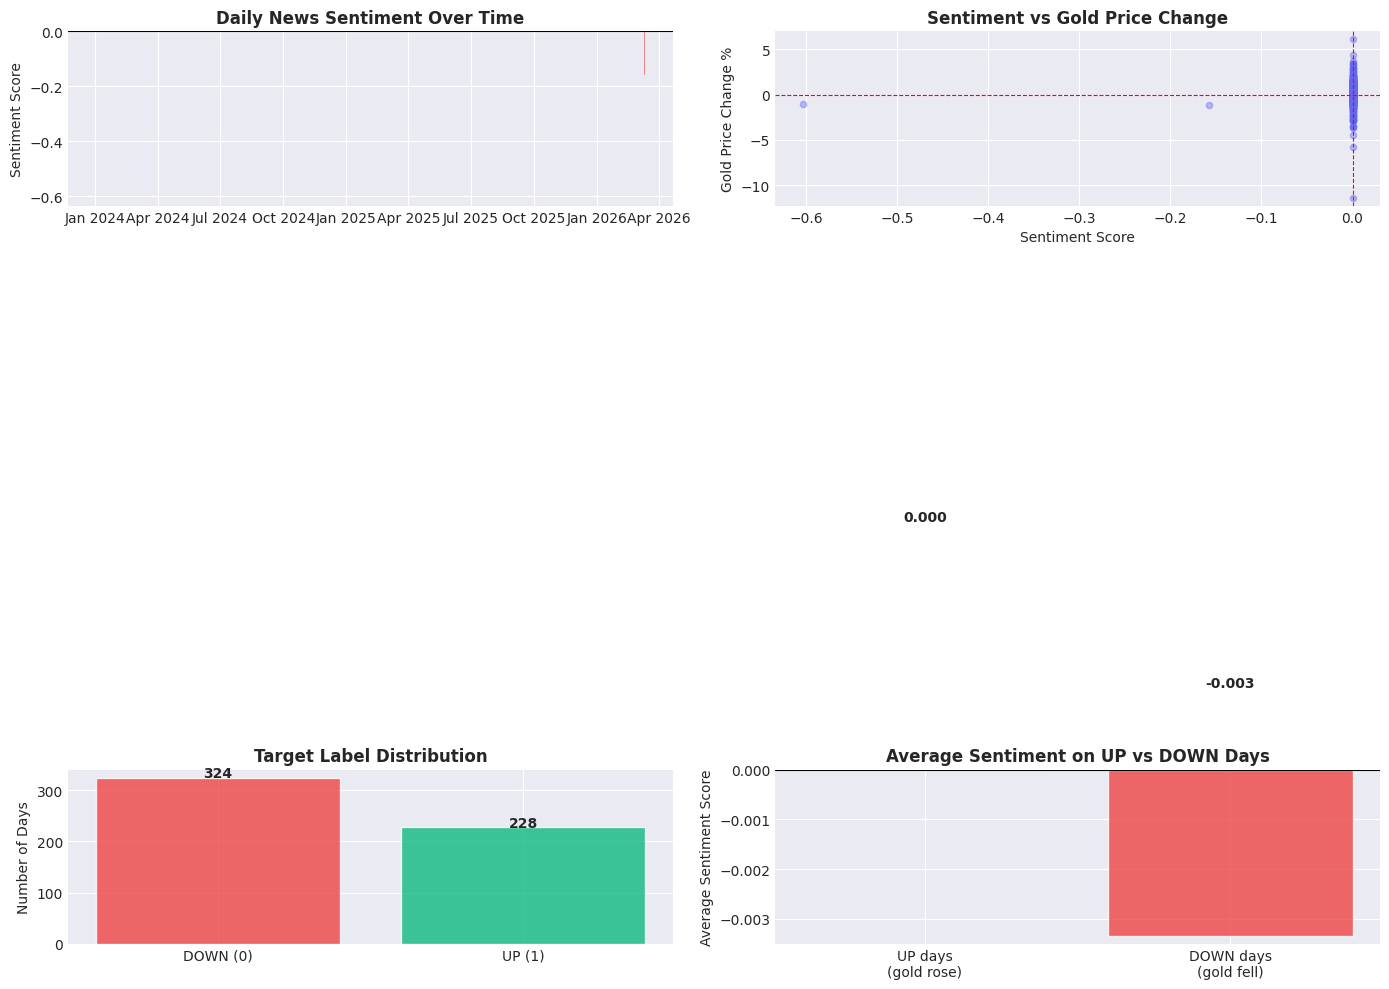

In [15]:
# Visualise the relationship between sentiment and gold price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — Sentiment over time
axes[0,0].bar(merged['date'], merged['sentiment_mean'],
              color=['#ef4444' if x < 0 else '#10b981' for x in merged['sentiment_mean']],
              alpha=0.6, width=1)
axes[0,0].axhline(y=0, color='black', linewidth=0.8)
axes[0,0].set_title('Daily News Sentiment Over Time', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Sentiment Score')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 2 — Gold price vs sentiment scatter
axes[0,1].scatter(merged['sentiment_mean'], merged['price_change_pct']*100,
                  alpha=0.4, color='#6366f1', s=20)
axes[0,1].axhline(y=0, color='red', linewidth=0.8, linestyle='--')
axes[0,1].axvline(x=0, color='red', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Sentiment vs Gold Price Change', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Sentiment Score')
axes[0,1].set_ylabel('Gold Price Change %')

# 3 — UP vs DOWN target distribution
target_counts = merged['target'].value_counts()
axes[1,0].bar(['DOWN (0)', 'UP (1)'], target_counts.values,
              color=['#ef4444', '#10b981'], alpha=0.8, edgecolor='white')
axes[1,0].set_title('Target Label Distribution', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Number of Days')
for i, v in enumerate(target_counts.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 4 — Average sentiment on UP vs DOWN days
up_sentiment   = merged[merged['target']==1]['sentiment_mean'].mean()
down_sentiment = merged[merged['target']==0]['sentiment_mean'].mean()
axes[1,1].bar(['UP days\n(gold rose)', 'DOWN days\n(gold fell)'],
              [up_sentiment, down_sentiment],
              color=['#10b981', '#ef4444'], alpha=0.8, edgecolor='white')
axes[1,1].axhline(y=0, color='black', linewidth=0.8)
axes[1,1].set_title('Average Sentiment on UP vs DOWN Days', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Average Sentiment Score')
for i, v in enumerate([up_sentiment, down_sentiment]):
    axes[1,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🤖 STEP 5 — Train the ML Models

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
import joblib

FEATURE_COLS = [
    'sentiment_mean', 'sentiment_min', 'sentiment_max', 'article_count',
    'prev_sentiment', 'price_change_pct', 'prev_price_change_pct', 'sentiment_7d_avg'
]

# Load training data
df = pd.read_csv(training_path)

X = df[FEATURE_COLS].fillna(0).values
y = df['target'].values

# Time-ordered 80/20 split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'📊 Dataset split:')
print(f'   Total rows  : {len(X)}')
print(f'   Training set: {len(X_train)} rows (80%) — older data')
print(f'   Test set    : {len(X_test)} rows (20%) — newer data')
print()
print(f'Training target distribution:')
print(f'   UP (1)  : {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'   DOWN (0): {len(y_train)-y_train.sum()} ({100*(1-y_train.mean()):.1f}%)')

📊 Dataset split:
   Total rows  : 552
   Training set: 441 rows (80%) — older data
   Test set    : 111 rows (20%) — newer data

Training target distribution:
   UP (1)  : 257 (58.3%)
   DOWN (0): 184 (41.7%)


In [17]:
# Define 3 candidate models
candidates = {
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=6,
            min_samples_leaf=5, random_state=42,
            class_weight='balanced'
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(
            n_estimators=100, max_depth=3,
            learning_rate=0.05, random_state=42
        ))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ))
    ]),
}

print('🔄 Running 5-fold cross-validation on all 3 models...')
print()
print(f'{"Model":<22} {"CV Mean":>10} {"CV Std":>10} {"Min":>8} {"Max":>8}')
print('-' * 62)

cv_results = {}
best_name, best_pipeline, best_cv = None, None, -1

for name, pipeline in candidates.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    cv_results[name] = cv_scores

    marker = ' ← BEST' if cv_mean > best_cv else ''
    print(f'{name:<22} {cv_mean:>10.4f} {cv_std:>10.4f} {cv_scores.min():>8.4f} {cv_scores.max():>8.4f}{marker}')

    if cv_mean > best_cv:
        best_cv = cv_mean
        best_name = name
        best_pipeline = pipeline

print()
print(f'🏆 Winner: {best_name} (CV accuracy: {best_cv:.4f})')

🔄 Running 5-fold cross-validation on all 3 models...

Model                     CV Mean     CV Std      Min      Max
--------------------------------------------------------------
Random Forest              0.4853     0.0098   0.4719   0.5000 ← BEST
Gradient Boosting          0.5624     0.0191   0.5341   0.5909 ← BEST
Logistic Regression        0.5125     0.0521   0.4659   0.6136

🏆 Winner: Gradient Boosting (CV accuracy: 0.5624)


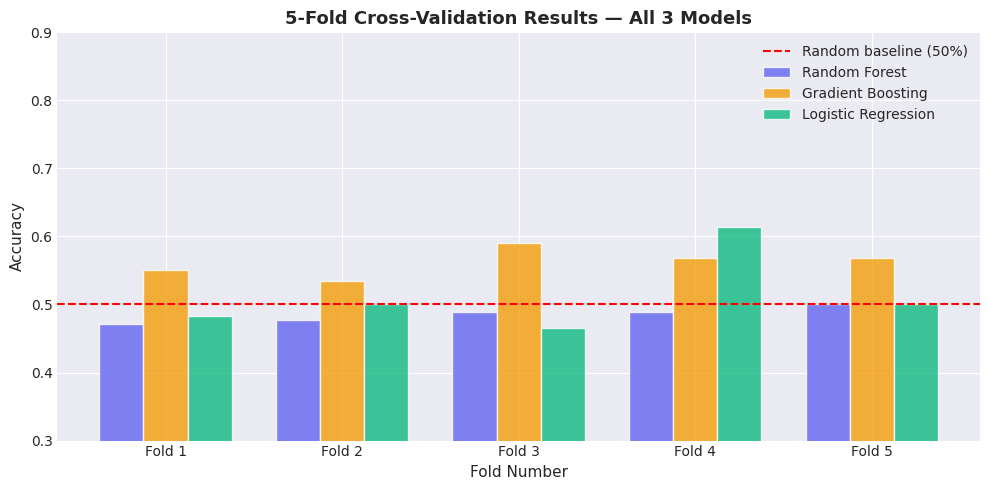

Red dashed line = random guessing (50%). Any bar above it = model learned something!


In [18]:
# Visualise cross-validation results
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#6366f1', '#f59e0b', '#10b981']
names  = list(cv_results.keys())
x      = np.arange(5)
width  = 0.25

for i, (name, scores) in enumerate(cv_results.items()):
    bars = ax.bar(x + i*width, scores, width, label=name,
                  color=colors[i], alpha=0.8, edgecolor='white')

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5,
           label='Random baseline (50%)')
ax.set_xlabel('Fold Number', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('5-Fold Cross-Validation Results — All 3 Models', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'])
ax.legend()
ax.set_ylim(0.3, 0.9)

plt.tight_layout()
plt.show()
print('Red dashed line = random guessing (50%). Any bar above it = model learned something!')

---
## 📊 STEP 6 — Evaluate the Best Model

In [19]:
# Train on full training set
print(f'🏋️  Training {best_name} on full training set...')
best_pipeline.fit(X_train, y_train)
print('✅ Training complete!')
print()

# Evaluate on test set
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f'📈 Results on TEST SET (data model never saw):')
print(f'   Accuracy : {acc:.4f} ({acc*100:.1f}%)')
print(f'   ROC-AUC  : {roc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['DOWN (0)', 'UP (1)']))

🏋️  Training Gradient Boosting on full training set...
✅ Training complete!

📈 Results on TEST SET (data model never saw):
   Accuracy : 0.5586 (55.9%)
   ROC-AUC  : 0.5083

Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.41      0.27      0.33        44
      UP (1)       0.61      0.75      0.67        67

    accuracy                           0.56       111
   macro avg       0.51      0.51      0.50       111
weighted avg       0.53      0.56      0.54       111



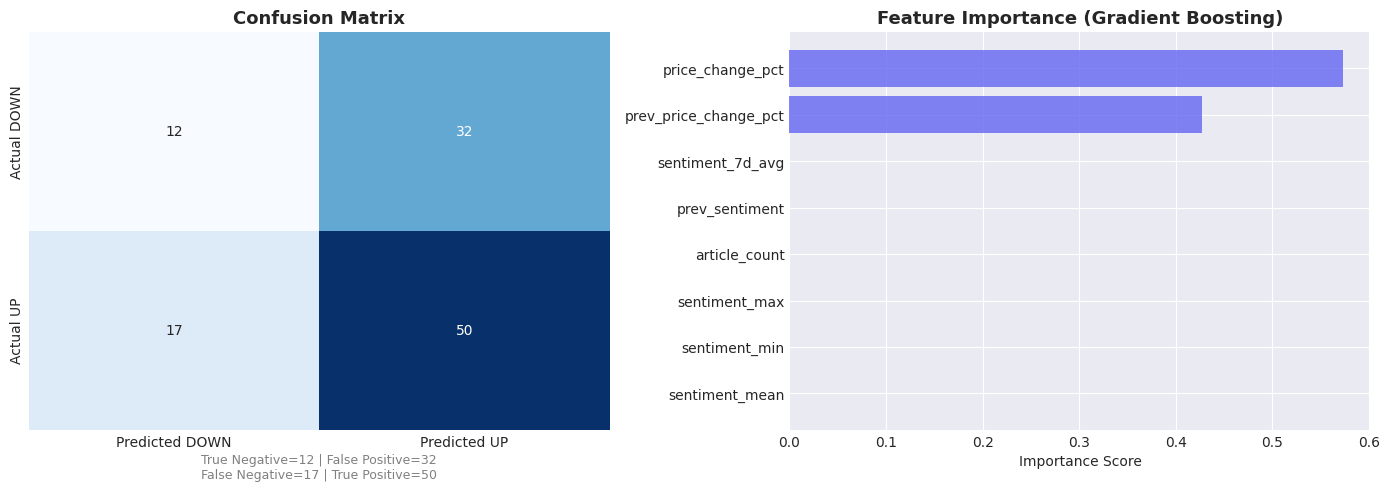

In [20]:
# Visualise results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted DOWN', 'Predicted UP'],
            yticklabels=['Actual DOWN', 'Actual UP'],
            ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# Annotation
axes[0].text(0.5, -0.12,
    f'True Negative={cm[0,0]} | False Positive={cm[0,1]}\n'
    f'False Negative={cm[1,0]} | True Positive={cm[1,1]}',
    transform=axes[0].transAxes, ha='center', fontsize=9, color='grey')

# Feature Importance
if hasattr(best_pipeline.named_steps.get('clf', None), 'feature_importances_'):
    importances = best_pipeline.named_steps['clf'].feature_importances_
    sorted_idx  = np.argsort(importances)
    axes[1].barh([FEATURE_COLS[i] for i in sorted_idx], importances[sorted_idx],
                 color='#6366f1', alpha=0.8)
    axes[1].set_title(f'Feature Importance ({best_name})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Importance Score')
else:
    # For Logistic Regression show coefficients
    coefs = best_pipeline.named_steps['clf'].coef_[0]
    sorted_idx = np.argsort(np.abs(coefs))
    axes[1].barh([FEATURE_COLS[i] for i in sorted_idx], coefs[sorted_idx],
                 color=['#10b981' if x > 0 else '#ef4444' for x in coefs[sorted_idx]],
                 alpha=0.8)
    axes[1].set_title(f'Feature Coefficients ({best_name})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Coefficient Value')
    axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [21]:
# Save the model
from datetime import date as date_cls
today_str   = date_cls.today().strftime('%Y%m%d')
model_path  = os.path.join(MODELS_DIR, f'gold_model_{today_str}.joblib')
latest_path = os.path.join(MODELS_DIR, 'gold_model_latest.joblib')

joblib.dump(best_pipeline, model_path)
joblib.dump(best_pipeline, latest_path)

print(f'💾 Model saved!')
print(f'   Timestamped: {model_path}')
print(f'   Latest:      {latest_path}')

💾 Model saved!
   Timestamped: /home/mimou/airflow/mid-semester/models/gold_model_20260314.joblib
   Latest:      /home/mimou/airflow/mid-semester/models/gold_model_latest.joblib


---
## 🔮 STEP 7 — Make Predictions

In [22]:
# Load and test the model
loaded_model = joblib.load(latest_path)
print('✅ Model loaded successfully!')
print()

# Test different scenarios
scenarios = {
    'Very negative war news day': [-0.80, -0.95, -0.50, 8, -0.60, -0.005, -0.003, -0.70],
    'Mild negative news':         [-0.35, -0.60, +0.10, 3, -0.25, +0.003, +0.002, -0.30],
    'No war news today':          [0.00,  0.00,   0.00, 0,  0.00, +0.001,  0.000,  0.00],
    'Positive news (ceasefire)':  [+0.55, +0.20, +0.85, 4, +0.30, +0.008, +0.005, +0.40],
    'Price was falling yesterday':[-0.40, -0.70, -0.10, 5, -0.30, -0.012, -0.008, -0.35],
}

print(f'{"Scenario":<35} {"Prediction":>12} {"Confidence":>12} {"P(UP)":>8} {"P(DOWN)":>8}')
print('-' * 80)

for scenario, features in scenarios.items():
    X_new = np.array([features])
    pred  = loaded_model.predict(X_new)[0]
    prob  = loaded_model.predict_proba(X_new)[0]

    direction  = '📈 UP' if pred == 1 else '📉 DOWN'
    confidence = max(prob)

    print(f'{scenario:<35} {direction:>12} {confidence:>11.1%} {prob[1]:>8.1%} {prob[0]:>8.1%}')

✅ Model loaded successfully!

Scenario                              Prediction   Confidence    P(UP)  P(DOWN)
--------------------------------------------------------------------------------
Very negative war news day                  📈 UP       58.6%    58.6%    41.4%
Mild negative news                          📈 UP       57.7%    57.7%    42.3%
No war news today                           📈 UP       57.0%    57.0%    43.0%
Positive news (ceasefire)                   📈 UP       70.5%    70.5%    29.5%
Price was falling yesterday                 📈 UP       74.3%    74.3%    25.7%


In [23]:
# Predict on the test set and compare to real prices
test_df = df.iloc[split:].copy().reset_index(drop=True)
test_df['predicted'] = y_pred
test_df['predicted_label'] = test_df['predicted'].map({1: 'UP', 0: 'DOWN'})
test_df['actual_label']    = test_df['target'].map({1: 'UP', 0: 'DOWN'})
test_df['correct']         = test_df['predicted'] == test_df['target']

print('🔍 Sample predictions vs reality (test set):')
print()
display(test_df[['date','close','sentiment_mean','article_count',
                  'predicted_label','actual_label','correct']].head(20))

🔍 Sample predictions vs reality (test set):



,date,close,sentiment_mean,article_count,predicted_label,actual_label,correct
0,2025-10-02,3839.699951,0.0,0.0,UP,UP,True
1,2025-10-03,3880.800049,0.0,0.0,UP,UP,True
2,2025-10-06,3948.500000,0.0,0.0,UP,UP,True
3,2025-10-07,3976.600098,0.0,0.0,UP,UP,True
4,2025-10-08,4043.300049,0.0,0.0,UP,DOWN,False
5,2025-10-09,3946.300049,0.0,0.0,UP,UP,True
6,2025-10-10,3975.899902,0.0,0.0,UP,UP,True
7,2025-10-13,4108.600098,0.0,0.0,DOWN,UP,False
8,2025-10-14,4138.700195,0.0,0.0,UP,UP,True
9,2025-10-15,4176.899902,0.0,0.0,DOWN,UP,False


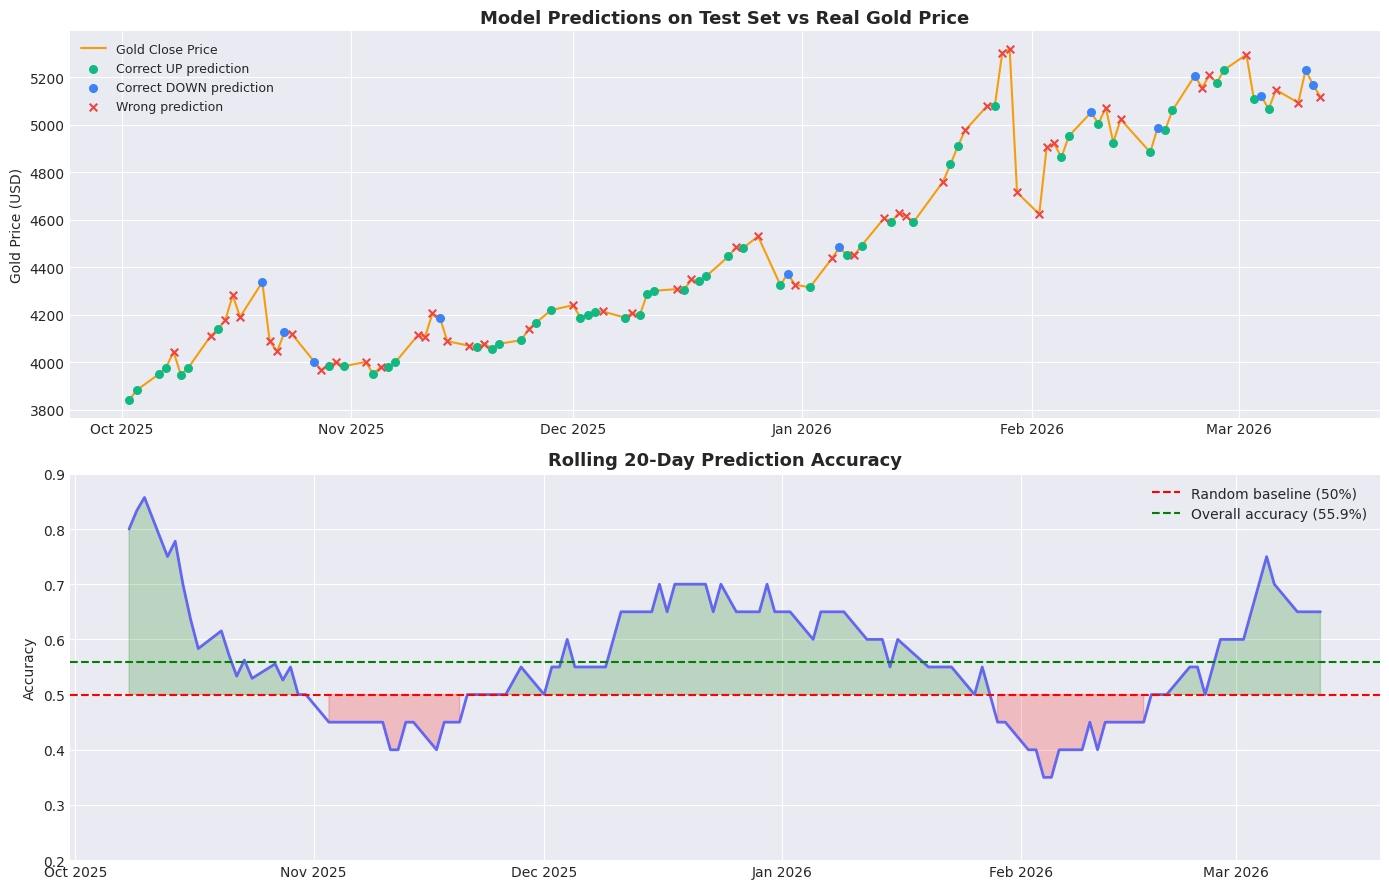

In [24]:
# Final visualisation — predictions vs reality over time
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Gold price on test set
test_df['date'] = pd.to_datetime(test_df['date'])
axes[0].plot(test_df['date'], test_df['close'], color='#f59e0b',
             linewidth=1.5, label='Gold Close Price')

# Mark correct predictions
correct_up   = test_df[(test_df['correct']==True)  & (test_df['predicted']==1)]
correct_down = test_df[(test_df['correct']==True)  & (test_df['predicted']==0)]
wrong        = test_df[test_df['correct']==False]

axes[0].scatter(correct_up['date'],   correct_up['close'],
                color='#10b981', s=30, zorder=5, label='Correct UP prediction')
axes[0].scatter(correct_down['date'], correct_down['close'],
                color='#3b82f6', s=30, zorder=5, label='Correct DOWN prediction')
axes[0].scatter(wrong['date'],        wrong['close'],
                color='#ef4444', s=30, zorder=5, marker='x', label='Wrong prediction')
axes[0].set_title('Model Predictions on Test Set vs Real Gold Price',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gold Price (USD)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rolling accuracy
test_df['rolling_accuracy'] = test_df['correct'].rolling(20, min_periods=5).mean()
axes[1].plot(test_df['date'], test_df['rolling_accuracy'],
             color='#6366f1', linewidth=2)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5,
                label='Random baseline (50%)')
axes[1].axhline(y=acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Overall accuracy ({acc:.1%})')
axes[1].fill_between(test_df['date'], 0.5, test_df['rolling_accuracy'],
                     where=test_df['rolling_accuracy'] >= 0.5,
                     alpha=0.2, color='green')
axes[1].fill_between(test_df['date'], test_df['rolling_accuracy'], 0.5,
                     where=test_df['rolling_accuracy'] < 0.5,
                     alpha=0.2, color='red')
axes[1].set_title('Rolling 20-Day Prediction Accuracy',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.2, 0.9)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

---
## ✅ STEP 8 — Final Summary

In [25]:
print('=' * 55)
print('  PIPELINE RESULTS SUMMARY')
print('=' * 55)
print()
print(f'📈 Gold Prices')
print(f'   Trading days collected : {len(gold_df)}')
print(f'   Date range             : {gold_df["date"].min().date()} → {gold_df["date"].max().date()}')
print(f'   Price range            : ${gold_df["close"].min():.2f} — ${gold_df["close"].max():.2f}')
print()
print(f'📰 War News')
print(f'   Articles collected     : {len(news_df)}')
print(f'   Negative articles      : {(news_df["compound"] < -0.05).sum()}')
print(f'   Positive articles      : {(news_df["compound"] > 0.05).sum()}')
print()
print(f'🔀 Training Dataset')
print(f'   Total rows             : {len(merged)}')
print(f'   Features               : {len(FEATURE_COLS)}')
print(f'   UP days (target=1)     : {merged["target"].sum()}')
print(f'   DOWN days (target=0)   : {len(merged) - merged["target"].sum()}')
print()
print(f'🤖 Machine Learning')
print(f'   Best model             : {best_name}')
print(f'   CV accuracy            : {best_cv:.4f} ({best_cv*100:.1f}%)')
print(f'   Test accuracy          : {acc:.4f} ({acc*100:.1f}%)')
print(f'   ROC-AUC                : {roc:.4f}')
print(f'   Model saved to         : {latest_path}')
print()
print('=' * 55)
print('  Pipeline Complete! ✅')
print('=' * 55)

  PIPELINE RESULTS SUMMARY

📈 Gold Prices
   Trading days collected : 553
   Date range             : 2024-01-02 → 2026-03-13
   Price range            : $1990.30 — $5318.40

📰 War News
   Articles collected     : 66
   Negative articles      : 50
   Positive articles      : 13

🔀 Training Dataset
   Total rows             : 552
   Features               : 8
   UP days (target=1)     : 324
   DOWN days (target=0)   : 228

🤖 Machine Learning
   Best model             : Gradient Boosting
   CV accuracy            : 0.5624 (56.2%)
   Test accuracy          : 0.5586 (55.9%)
   ROC-AUC                : 0.5083
   Model saved to         : /home/mimou/airflow/mid-semester/models/gold_model_latest.joblib

  Pipeline Complete! ✅
